# Section 2 & 3: Heterogeneity, Segmentation, and Statistical Rigor

Runs on the full untouched randomized Criteo data (not the artificially confounded subsample
from `01_validation.ipynb`), since heterogeneity estimates should be built on the cleanest data
available. `visit` is the outcome throughout, per the Section 1.5 MDE justification.

**Sequence:**
1. Load data, subsample to a CPU-feasible size.
2. Fit a T-learner, evaluate it with the Qini coefficient on a held-out split (don't trust it
   just because it ran).
3. Segment users via clustering, measure the treatment effect per segment.
4. Apply Benjamini-Hochberg correction across segments.
5. Run per-segment power analysis, surfacing which segment findings are actually well-powered.

In [1]:
import os, sys

# Jupyter sets the kernel's cwd to this notebook's own folder (notebooks/),
# but src/ lives one level up, as a sibling of notebooks/, not a child of it.
# This makes 'from src...' imports resolve regardless of how the notebook
# was launched (jupyter notebook from the project root vs from notebooks/).
_cwd = os.getcwd()
_project_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)


In [2]:
import json
import os

import numpy as np
import pandas as pd

from src.utils.logging_config import configure_logging
from src.utils.data_loader import load_criteo_uplift
from src.utils.power_analysis import segment_power_analysis
from src.heterogeneity.cate import t_learner_pipeline
from src.heterogeneity.segmentation import cluster_segments, quantile_segments, compute_segment_effects
from src.heterogeneity.evaluation import evaluate_cate_qini, plot_qini, apply_benjamini_hochberg

configure_logging()

os.makedirs("../data/processed", exist_ok=True)

RANDOM_STATE = 42
SUBSAMPLE_N = 300_000  # CPU-feasible subsample, drawn from the untouched randomized pool
N_CLUSTERS = 4

FEATURE_COLS = [f"f{i}" for i in range(12)]

14:38:12.834 Structured logging configured via Logfire


## 1. Load data and subsample

In [3]:
df = load_criteo_uplift(validate=True)

subsample = df.sample(n=SUBSAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)
print(subsample.shape)
print("treatment share:", subsample["treatment"].mean())
print("visit rate:", subsample["visit"].mean())

14:38:12.844 Attempting load from Hugging Face (criteo/criteo-uplift)


14:38:14.246 HTTP Request: HEAD https://huggingface.co/datasets/criteo/criteo-uplift/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
14:38:14.246 Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
14:38:14.277 HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/criteo/criteo-uplift/2424920019e49d52d72c13ac1143ec5d53af276b/README.md "HTTP/1.1 200 OK"
14:38:14.547 HTTP Request: HEAD https://huggingface.co/datasets/criteo/criteo-uplift/resolve/2424920019e49d52d72c13ac1143ec5d53af276b/criteo-uplift.py "HTTP/1.1 404 Not Found"


Logfire project URL: https://logfire-us.pydantic.dev/abhinewnpc/ticket-triage-mlops

14:38:16.112 HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/criteo/criteo-uplift/criteo/criteo-uplift.py "HTTP/1.1 404 Not Found"
14:38:16.380 HTTP Request: GET https://huggingface.co/api/datasets/criteo/criteo-uplift/revision/2424920019e49d52d72c13ac1143ec5d53af276b "HTTP/1.1 200 OK"
14:38:16.657 HTTP Request: HEAD https://huggingface.co/datasets/criteo/criteo-uplift/resolve/2424920019e49d52d72c13ac1143ec5d53af276b/.huggingface.yaml "HTTP/1.1 404 Not Found"
14:38:17.080 HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=criteo/criteo-uplift "HTTP/1.1 200 OK"
14:38:17.357 HTTP Request: GET https://huggingface.co/api/datasets/criteo/criteo-uplift/tree/2424920019e49d52d72c13ac1143ec5d53af276b/data?recursive=true&expand=false "HTTP/1.1 404 Not Found"
14:38:17.619 HTTP Request: GET https://huggingface.co/api/datasets/criteo/criteo-uplift/tree/2424920019e49d52d72c13ac1143ec5d53af276b?recursive=false&expand=false "HTTP/1.1 200 OK"
14:

## 2. T-learner CATE estimation

Splits into train/holdout (stratified by treatment), fits calibrated base classifiers on each
arm, and predicts CATE on the holdout set. Base classifiers are calibrated because `visit`'s
low base rate (~4-5%) can otherwise produce systematically off probability estimates, which
directly noises up the CATE difference.

Causal forest / X-learner would be a natural next step here, but is intentionally not built,
to protect feasibility — the T-learner is simpler to explain and defend, which matters more
for this project than squeezing out marginal accuracy.

In [4]:
t_learner_result = t_learner_pipeline(
    subsample,
    feature_cols=FEATURE_COLS,
    treatment_col="treatment",
    outcome_col="visit",
    calibrate=True,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

holdout_df = t_learner_result["holdout_df"]
holdout_df[["cate"]].describe()

14:38:20.968 T-learner fit: 178401 treated units, 31599 control units, calibrate=True (method=sigmoid)
14:38:21.031 Holdout CATE summary: mean=0.00669, std=0.02389, min=-0.09192, max=0.50336


,cate
count,90000.000000
mean,0.006690
std,0.023891
min,-0.091920
25%,-0.000019
50%,0.000614
75%,0.003207
max,0.503362


In [5]:
extreme_rows = holdout_df.nlargest(5, "cate")
print(extreme_rows[FEATURE_COLS + ["treatment", "visit", "cate"]])
print()
print(holdout_df[FEATURE_COLS].describe())

               f0         f1        f2        f3         f4        f5  \
136295  12.865772  10.059654  8.287923  0.604065  10.280525 -2.858198   
71130   13.287075  10.059654  8.672441 -4.461691  11.029584 -2.144875   
229042  13.052313  11.974826  8.240165 -4.633926  10.280525 -3.155091   
44496   14.095255  10.679513  8.352404 -2.934805  14.792535 -1.858418   
268162  14.449213  10.679513  8.326273 -3.931992  10.280525 -0.756029   

               f6        f7        f8         f9       f10       f11  \
136295 -20.376678  9.028566  3.751603  41.938600  5.300375 -0.168679   
71130  -23.611998  9.006840  3.759041  25.240993  5.987178 -0.168679   
229042 -22.968081  7.263417  3.775827  44.503859  5.300375 -0.168679   
44496  -21.565066  6.370030  3.719462  43.847149  5.778339 -0.337358   
268162 -22.761235  6.375045  3.795498  40.022256  5.300375 -0.168679   

        treatment  visit      cate  
136295          1      1  0.503362  
71130           1      1  0.491857  
229042          1

## 3. Qini evaluation

Never treat the T-learner's output as correct just because it ran. The Qini coefficient
quantifies whether the predicted CATE actually ranks units by true uplift better than random
targeting would.

14:38:21.149 Qini coefficient: 0.05986
Qini coefficient: 0.05986465965374447


c:\Users\abhin\Desktop\Important\codes\projects\causal-impact-lab\venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\abhin\Desktop\Important\codes\projects\causal-impact-lab\venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


14:38:23.200 generated new fontManager


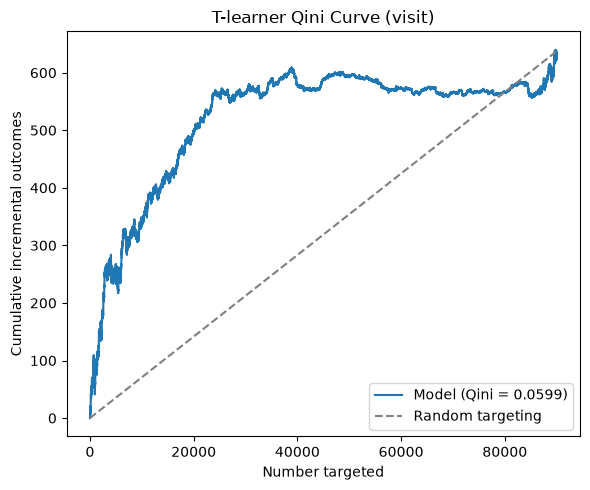

In [6]:
qini_result = evaluate_cate_qini(holdout_df, cate_col="cate", outcome_col="visit", treatment_col="treatment")
print("Qini coefficient:", qini_result["qini_coefficient"])

fig = plot_qini(qini_result, title="T-learner Qini Curve (visit)")
fig.savefig("../data/processed/qini_curve.png", dpi=100)

with open("../data/processed/qini_curve.json", "w") as f:
    json.dump(
        {
            "curve_x": list(map(float, qini_result["curve_x"])),
            "curve_y": list(map(float, qini_result["curve_y"])),
            "qini_coefficient": float(qini_result["qini_coefficient"]),
        },
        f,
    )

A Qini coefficient meaningfully above 0 means the model beats random targeting; close to 0
means the CATE estimates aren't capturing real heterogeneity, and the segmentation below should
be interpreted with that in mind.

## 4. Segmentation

Two options are available: unsupervised clustering on pre-treatment covariates (primary), or a
business-style quantile split on a single covariate. Criteo's covariates are anonymized dense
floats (not literal recency/frequency/value fields), so clustering is the more natural default
here; the quantile split is included as a simpler, more interpretable alternative when a single
covariate already captures most of the relevant variation.

In [7]:
holdout_df = holdout_df.copy()
holdout_df["segment"] = cluster_segments(holdout_df, FEATURE_COLS, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
holdout_df["segment"].value_counts()

14:38:27.189 KMeans clustering: 4 clusters on 90000 rows


segment
cluster_2    46542
cluster_3    35312
cluster_1     4400
cluster_0     3746
Name: count, dtype: int64

In [8]:
# Alternative business-style split, included for comparison but not used as the primary
# segmentation below (uncomment to explore):
# most_predictive_feature = holdout_df.groupby("segment")["f0"].mean().abs().idxmax()
# holdout_df["value_segment"] = quantile_segments(holdout_df, "f0", n_bins=4)

## 5. Per-segment treatment effects

Naive difference-in-means per segment, with bootstrap CIs and a two-proportion z-test p-value
per segment (the p-value feeds into the Benjamini-Hochberg correction below).

In [9]:
segment_effects = compute_segment_effects(
    holdout_df,
    segment_col="segment",
    treatment_col="treatment",
    outcome_col="visit",
    n_bootstrap=1000,
    random_state=RANDOM_STATE,
)
segment_effects

14:38:28.025 Computed segment effects for 4 segments


,segment,n_segment,n_treated,n_control,point_estimate,ci_lower,ci_upper,p_value,mean_predicted_cate
0,cluster_0,3746,3214,532,0.026540,-0.015631,0.064669,0.226879,0.033630
1,cluster_1,4400,3790,610,0.050335,0.026889,0.073687,0.000424,0.033717
2,cluster_2,46542,39573,6969,0.000719,-0.000588,0.001951,0.315370,0.000772
3,cluster_3,35312,29880,5432,0.009631,0.002817,0.016661,0.009399,0.008265


## 6. Section 3: Multiple comparison correction

Testing many segments at once inflates the chance of a false positive. Benjamini-Hochberg
correction is applied here before any per-segment effect is reported as statistically real.

In [10]:
segment_effects_bh = apply_benjamini_hochberg(segment_effects, p_value_col="p_value", alpha=0.05)
segment_effects_bh.to_csv("../data/processed/segment_effects.csv", index=False)

n_significant = segment_effects_bh["significant_after_correction"].sum()
print(f"{n_significant} of {len(segment_effects_bh)} segments remain significant after BH correction")
segment_effects_bh[["segment", "point_estimate", "p_value", "p_value_adjusted", "significant_after_correction"]]

2 of 4 segments remain significant after BH correction


,segment,point_estimate,p_value,p_value_adjusted,significant_after_correction
0,cluster_0,0.026540,0.226879,0.302505,False
1,cluster_1,0.050335,0.000424,0.001695,True
2,cluster_2,0.000719,0.315370,0.315370,False
3,cluster_3,0.009631,0.009399,0.018798,True


## 7. Section 3: Per-segment power analysis

Surfaces a common real-world mistake: running per-segment significance tests without checking
whether each segment is even large enough to detect the assumed effect size. Because Section
1.5 already steered the outcome variable toward `visit` for signal reasons, an underpowered
finding here reflects genuine segment-level sample size limits, not a self-inflicted labeling
problem.

In [ ]:
segment_sizes = segment_effects_bh.set_index("segment")["n_segment"].to_dict()
treatment_share = holdout_df["treatment"].mean()

# Assumed effect size for the power calculation: Section 1's ground-truth ATE is a
# more defensible anchor than the segment effects computed just above, since using
# those directly would be circular (a post-hoc "power" computed from the same data
# used to produce the p-values above is close to a deterministic function of those
# p-values, and adds little real information about whether the study was adequately
# powered). Fall back to the segment-effect median only if Section 1 hasn't been run,
# and say so explicitly rather than silently using the circular version.
ground_truth_path = "../data/processed/ground_truth.json"
if os.path.exists(ground_truth_path):
    with open(ground_truth_path) as f:
        ground_truth = json.load(f)
    assumed_effect_size = abs(ground_truth["ate"])
    print(f"Using Section 1's ground-truth ATE as the assumed effect size: {assumed_effect_size:.5f}")
else:
    assumed_effect_size = segment_effects_bh["point_estimate"].abs().median()
    print(
        "WARNING: ../data/processed/ground_truth.json not found (run 01_validation.ipynb "
        "first). Falling back to the median observed segment effect as the assumed effect "
        "size. This makes the power calculation below post-hoc / illustrative only, since "
        "the assumed effect is derived from the same data used to compute the p-values above."
    )

segment_power = segment_power_analysis(
    segment_sizes,
    baseline_rate=subsample["visit"].mean(),
    true_effect_absolute=assumed_effect_size,
    treatment_share=treatment_share,
)
segment_power.to_csv("../data/processed/segment_power.csv", index=False)

n_underpowered = segment_power["underpowered"].sum()
print(f"{n_underpowered} of {len(segment_power)} segments are underpowered at the assumed effect size")
segment_power


## Summary

- T-learner CATE fit on train, evaluated on holdout via Qini (never assumed correct by default).
- Users segmented via clustering on pre-treatment covariates.
- Per-segment treatment effects computed with bootstrap CIs.
- Benjamini-Hochberg correction applied across segments before calling any finding significant.
- Per-segment power analysis flags which segments are large enough to trust.

All of these artifacts feed the dashboard (`streamlit run dashboard/app.py`).